# Projet 2 — Classification de variétés de riz par caractéristiques morphologiques
## Dataset : Rice (Cammeo and Osmancik) — UCI Machine Learning Repository (ID: 545)

**Auteur :** Youssef EL GHARBAOUI  
**Date :** Juin 2026  
**Source officielle :** https://archive.ics.uci.edu/dataset/545/rice+cammeo+and+osmancik  
**Référence GitHub (miroir) :** https://github.com/sbt5731/Rice-Cammeo-Osmancik  

---

**Problématique :** Peut-on distinguer automatiquement deux variétés de riz (Cammeo et Osmancik) à partir de mesures morphologiques extraites d'images ?


## 01 — Importation des bibliothèques

In [1]:
# Manipulation des données
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Prétraitement & modélisation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Style global des graphiques
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")
sns.set_palette("Set2")

print("✅ Bibliothèques importées avec succès.")
print(f"   pandas      : {pd.__version__}")
print(f"   numpy       : {np.__version__}")
import sklearn; print(f"   scikit-learn: {sklearn.__version__}")


✅ Bibliothèques importées avec succès.
   pandas      : 3.0.2
   numpy       : 2.4.4
   scikit-learn: 1.8.0


## 02 — Chargement du dataset

In [2]:
# ─────────────────────────────────────────────────────────────────
#  Source officielle : UCI ML Repository — Rice (Cammeo and Osmancik)
#  URL : https://archive.ics.uci.edu/dataset/545/rice+cammeo+and+osmancik
#  Référence : Cinar, I., Koklu, M. (2019). Classification of Rice Varieties
#              Using Artificial Intelligence Methods. IJISAE, 7(3), 188-194.
#  Chargement depuis le miroir GitHub (reproductible sans compte) :
#  https://raw.githubusercontent.com/sbt5731/Rice-Cammeo-Osmancik/main/Rice_Cammeo_Osmancik.csv
# ─────────────────────────────────────────────────────────────────

URL = "https://raw.githubusercontent.com/sbt5731/Rice-Cammeo-Osmancik/main/Rice_Cammeo_Osmancik.csv"

try:
    df = pd.read_csv(URL)
    print(f"✅ Dataset chargé depuis GitHub (miroir UCI).")
except Exception:
    # Chargement local si le réseau n'est pas disponible
    df = pd.read_csv("Rice_Cammeo_Osmancik.csv")
    print("✅ Dataset chargé depuis le fichier local.")

print(f"\nDimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head()


✅ Dataset chargé depuis GitHub (miroir UCI).

Dimensions : 3810 lignes × 8 colonnes


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo


## 03 — Compréhension du problème

In [3]:
# ─── Reformulation de la problématique ───────────────────────────
print("""
📌 PROBLÉMATIQUE
================
L'objectif est de construire un modèle de classification binaire capable
de distinguer automatiquement deux variétés de riz — Cammeo et Osmancik —
uniquement à partir de 7 mesures morphologiques extraites d'images numériques.

ENJEU MÉTIER
============
En agriculture et en contrôle qualité, trier manuellement des grains de riz
par variété est coûteux et peu reproductible. Un modèle prédictif fiable
peut automatiser ce tri, réduire les erreurs humaines et accélérer la chaîne
de production.

NATURE DU PROBLÈME
==================
• Type         : Classification supervisée binaire
• Variable cible: Class (Cammeo / Osmancik)
• Données      : Mesures continues issues du traitement d'image
• Évaluation   : Accuracy, Précision, Rappel, F1-score, Matrice de confusion

HYPOTHÈSE PRINCIPALE
====================
Les deux variétés présentent des différences morphologiques mesurables
(forme, taille, élongation) qui permettent une séparation statistique fiable.
""")



📌 PROBLÉMATIQUE
L'objectif est de construire un modèle de classification binaire capable
de distinguer automatiquement deux variétés de riz — Cammeo et Osmancik —
uniquement à partir de 7 mesures morphologiques extraites d'images numériques.

ENJEU MÉTIER
En agriculture et en contrôle qualité, trier manuellement des grains de riz
par variété est coûteux et peu reproductible. Un modèle prédictif fiable
peut automatiser ce tri, réduire les erreurs humaines et accélérer la chaîne
de production.

NATURE DU PROBLÈME
• Type         : Classification supervisée binaire
• Variable cible: Class (Cammeo / Osmancik)
• Données      : Mesures continues issues du traitement d'image
• Évaluation   : Accuracy, Précision, Rappel, F1-score, Matrice de confusion

HYPOTHÈSE PRINCIPALE
Les deux variétés présentent des différences morphologiques mesurables
(forme, taille, élongation) qui permettent une séparation statistique fiable.



## 04 — Description du dataset

In [4]:
# Descriptions des variables
descriptions = {
    "Area"            : "Nombre de pixels dans les limites du grain de riz (taille globale)",
    "Perimeter"       : "Perimetre du grain calcule par le nombre de pixels sur le contour",
    "Major_Axis_Length": "Longueur du plus grand axe de l ellipse ajustee au grain",
    "Minor_Axis_Length": "Longueur du plus petit axe de l ellipse ajustee au grain",
    "Eccentricity"    : "Mesure de l elongation : 0 = cercle parfait, 1 = ligne droite",
    "Convex_Area"     : "Aire de la plus petite enveloppe convexe englobant le grain",
    "Extent"          : "Rapport entre l aire du grain et celle du rectangle englobant",
    "Class"           : "Variete de riz : Cammeo (arrondi) ou Osmancik (allonge) [CIBLE]"
}

desc_df = pd.DataFrame({
    "Variable": list(descriptions.keys()),
    "Description": list(descriptions.values()),
    "Type": ["Numerique continue" if k != "Class" else "Categorielle binaire (cible)"
             for k in descriptions.keys()]
})
print(desc_df.to_string(index=False))

print(f"\n{'='*50}")
print(f"Dimensions   : {df.shape[0]} observations x {df.shape[1]} variables")
print(f"Predicteurs  : {df.shape[1]-1} variables morphologiques continues")
print(f"Cible        : 1 variable categorielle binaire (Class)")
print(f"{'='*50}")

         Variable                                                        Description                         Type
             Area Nombre de pixels dans les limites du grain de riz (taille globale)           Numerique continue
        Perimeter  Perimetre du grain calcule par le nombre de pixels sur le contour           Numerique continue
Major_Axis_Length           Longueur du plus grand axe de l ellipse ajustee au grain           Numerique continue
Minor_Axis_Length           Longueur du plus petit axe de l ellipse ajustee au grain           Numerique continue
     Eccentricity      Mesure de l elongation : 0 = cercle parfait, 1 = ligne droite           Numerique continue
      Convex_Area        Aire de la plus petite enveloppe convexe englobant le grain           Numerique continue
           Extent      Rapport entre l aire du grain et celle du rectangle englobant           Numerique continue
            Class    Variete de riz : Cammeo (arrondi) ou Osmancik (allonge) [CIBLE] Cat

In [5]:
# ─── Aperçu des types et des premières valeurs ───────────────────
print("Types de données :")
print(df.dtypes)
print("\nAperçu des 5 premières lignes :")
df.head()


Types de données :
Area                   int64
Perimeter            float64
Major_Axis_Length    float64
Minor_Axis_Length    float64
Eccentricity         float64
Convex_Area            int64
Extent               float64
Class                    str
dtype: object

Aperçu des 5 premières lignes :


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo


In [6]:
# ─── Statistiques descriptives ───────────────────────────────────
df.describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
Area,3810.0,12667.728,1732.368,7551.000,11370.500,12421.500,13950.000,18913.000
Perimeter,3810.0,454.239,35.597,359.100,426.145,448.852,483.684,548.446
Major_Axis_Length,3810.0,188.776,17.449,145.264,174.354,185.810,203.550,239.010
Minor_Axis_Length,3810.0,86.314,5.730,59.532,82.732,86.435,90.144,107.542
Eccentricity,3810.0,0.887,0.021,0.777,0.872,0.889,0.903,0.948
Convex_Area,3810.0,12952.497,1776.972,7723.000,11626.250,12706.500,14284.000,19099.000
Extent,3810.0,0.662,0.077,0.497,0.599,0.645,0.727,0.861


## 05 — Analyse exploratoire des données (EDA)

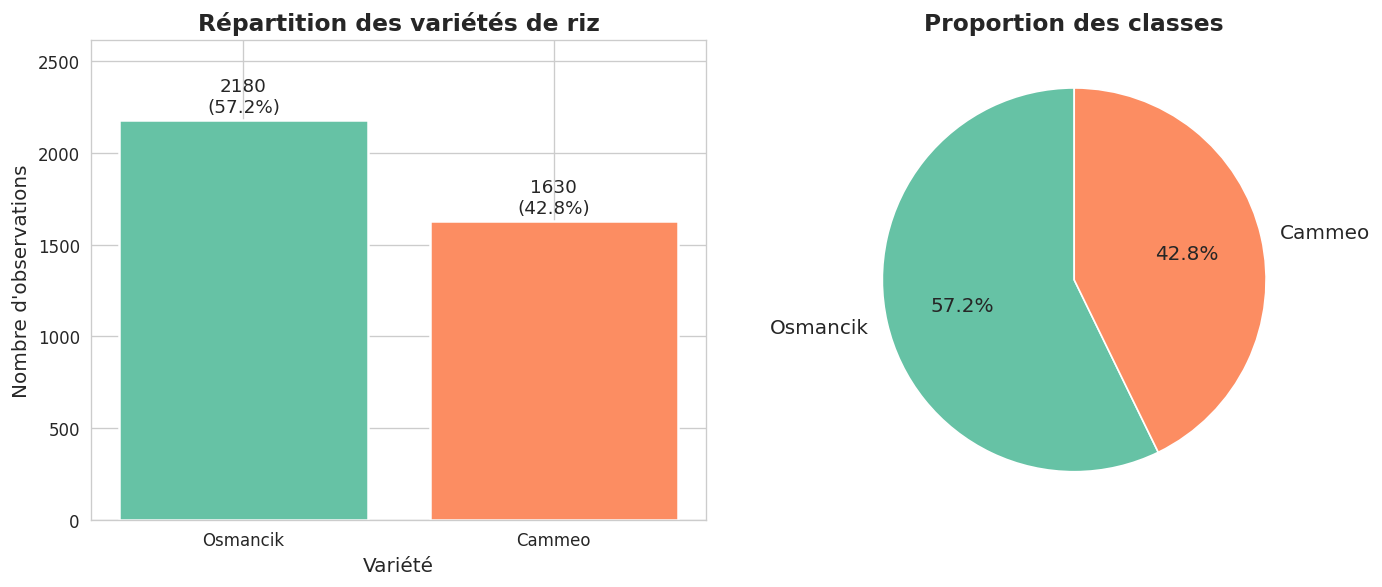


📊 COMMENTAIRE — Répartition des classes
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Le dataset contient 2 180 grains d'Osmancik (57.2 %) et 1 630 grains de Cammeo (42.8 %).
Le déséquilibre est modéré (~1.3:1) : il ne nécessite pas de rééchantillonnage agressif,
mais la stratification du split train/test est indispensable pour le préserver.
La mesure du F1-score par classe sera utile pour détecter tout biais du modèle
en faveur de la classe majoritaire (Osmancik).



In [7]:
# ─── Répartition des classes ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Countplot
counts = df['Class'].value_counts()
colors = ['#66c2a5', '#fc8d62']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Répartition des variétés de riz', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Variété', fontsize=12)
axes[0].set_ylabel('Nombre d\'observations', fontsize=12)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=11)
axes[0].set_ylim(0, counts.max() * 1.2)

# Camembert
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proportion des classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_01_class_distribution.png', bbox_inches='tight')
plt.show()

print("""
📊 COMMENTAIRE — Répartition des classes
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Le dataset contient 2 180 grains d'Osmancik (57.2 %) et 1 630 grains de Cammeo (42.8 %).
Le déséquilibre est modéré (~1.3:1) : il ne nécessite pas de rééchantillonnage agressif,
mais la stratification du split train/test est indispensable pour le préserver.
La mesure du F1-score par classe sera utile pour détecter tout biais du modèle
en faveur de la classe majoritaire (Osmancik).
""")


In [8]:
# ─── Statistiques par classe ─────────────────────────────────────
features = ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length',
            'Eccentricity', 'Convex_Area', 'Extent']

stats_by_class = df.groupby('Class')[features].agg(['mean', 'std', 'median']).round(3)
print("Statistiques descriptives par classe :\n")
print(stats_by_class.to_string())


Statistiques descriptives par classe :

               Area                    Perimeter                 Major_Axis_Length                  Minor_Axis_Length                Eccentricity               Convex_Area                    Extent              
               mean       std   median      mean     std  median              mean     std   median              mean    std  median         mean    std median        mean       std   median   mean    std median
Class                                                                                                                                                                                                              
Cammeo    14162.892  1286.771  14212.0   487.439  22.182  488.18           205.479  10.334  205.717            88.768  5.350  88.831        0.901  0.013  0.902   14494.427  1309.419  14536.5  0.651  0.082  0.634
Osmancik  11549.783  1041.909  11552.5   429.416  20.154  429.24           176.288   9.362  175.665            8

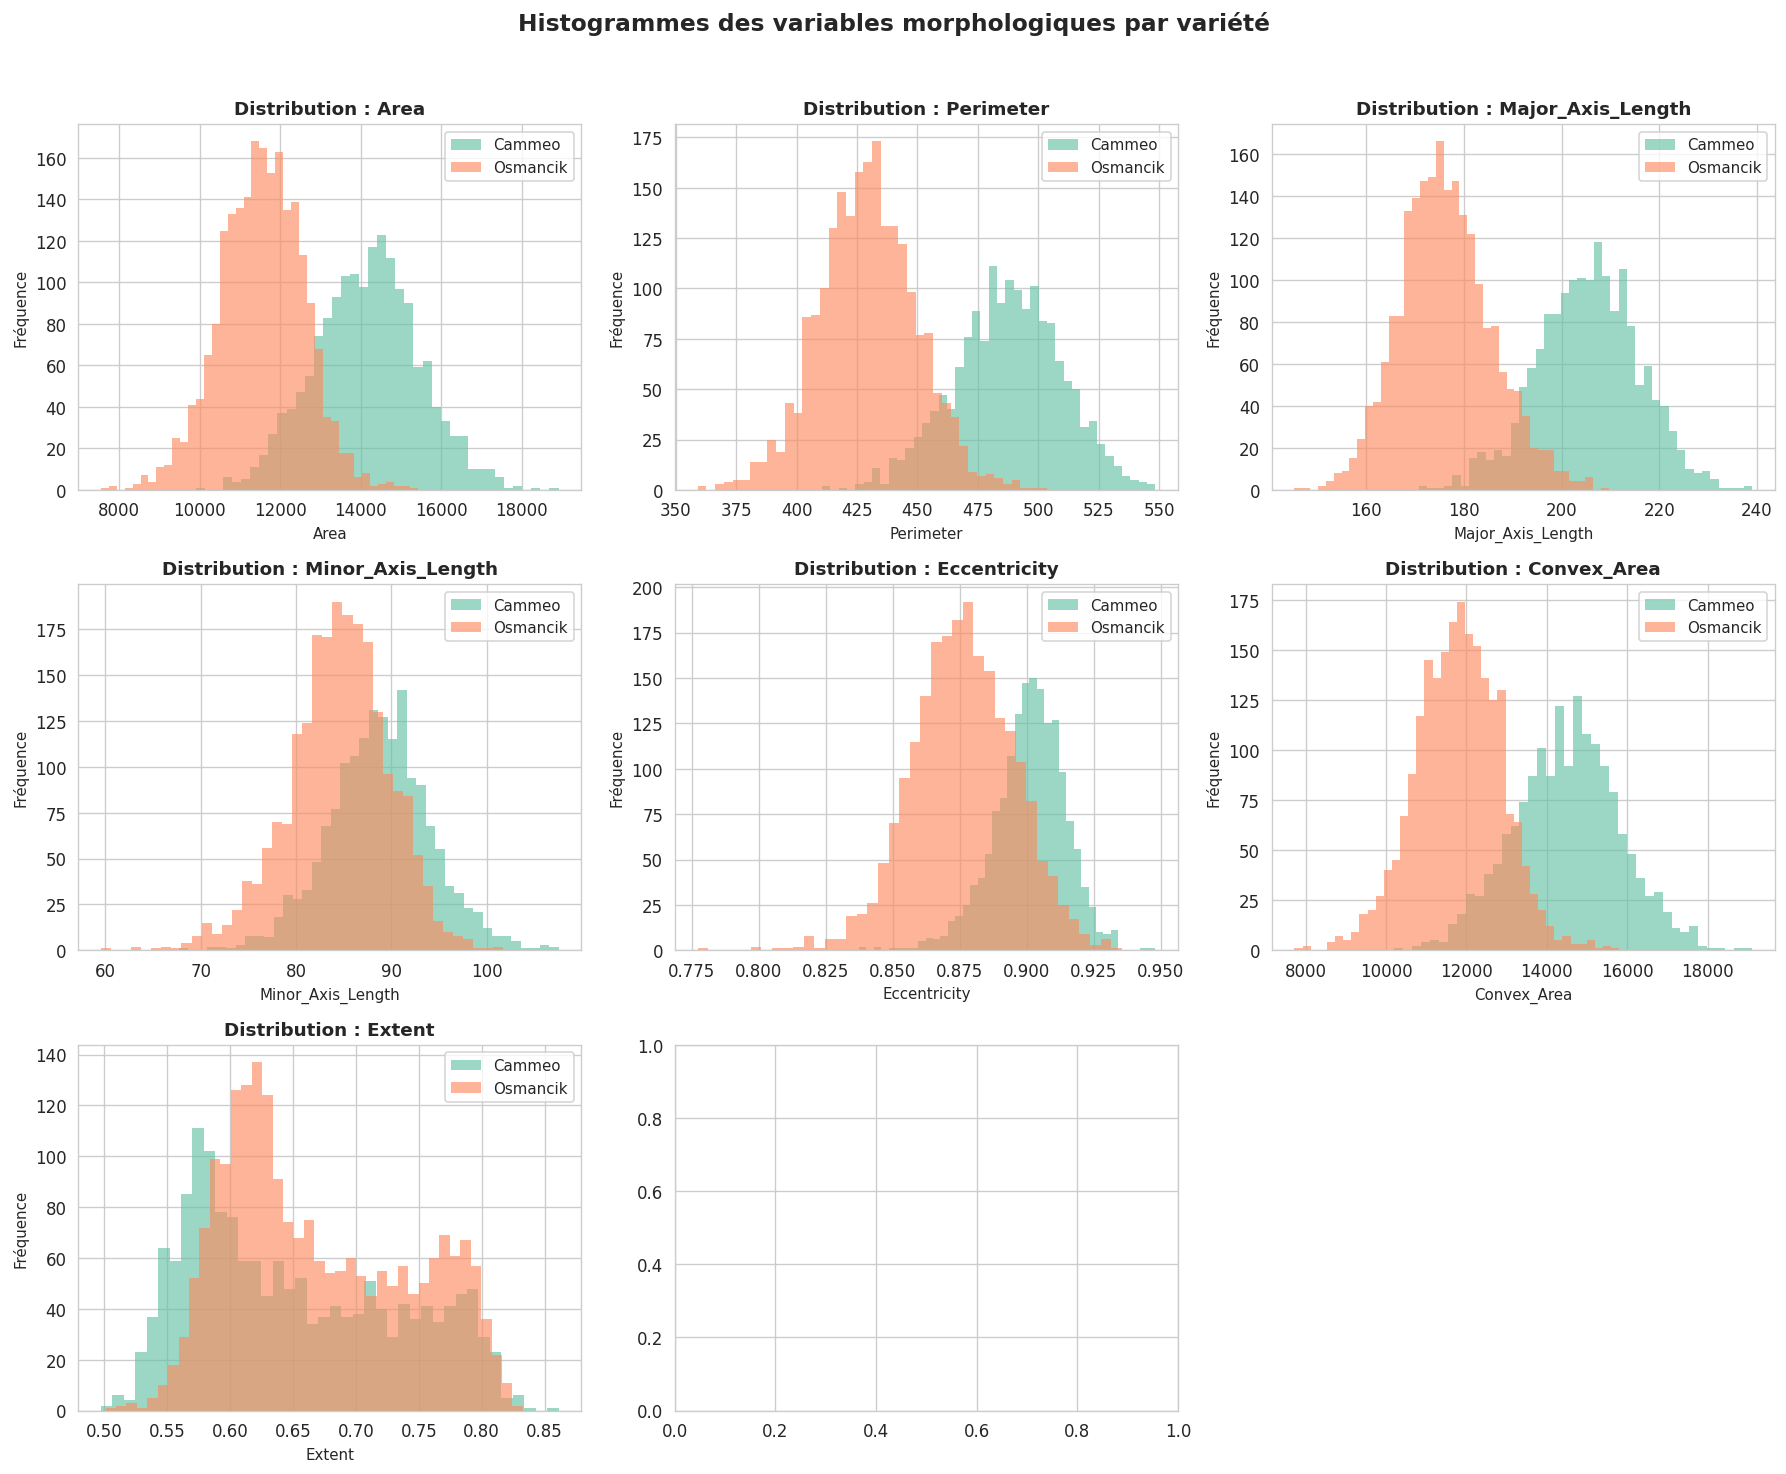


📊 COMMENTAIRE — Histogrammes par variable
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Area & Convex_Area : Cammeo présente une aire moyenne nettement supérieure, 
  indiquant des grains plus larges et plus lourds.
• Major_Axis_Length : les distributions se chevauchent fortement — l'axe principal 
  seul est peu discriminant.
• Minor_Axis_Length : Cammeo affiche un axe mineur plus large, cohérent avec sa forme arrondie.
• Eccentricity : Osmancik est significativement plus excentrique (plus allongé), 
  ce qui en fait probablement le meilleur discriminant.
• Extent : Cammeo remplit mieux son rectangle englobant (grains plus compacts).
Ces observations suggèrent que l'eccentricité et le ratio axe mineur/axe majeur 
seront les variables les plus importantes pour la classification.



In [9]:
# ─── Histogrammes par variable et par classe ─────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
palette = {'Cammeo': '#66c2a5', 'Osmancik': '#fc8d62'}

for i, feat in enumerate(features):
    for cls, color in palette.items():
        data = df[df['Class'] == cls][feat]
        axes[i].hist(data, bins=40, alpha=0.65, color=color, label=cls, edgecolor='none')
    axes[i].set_title(f'Distribution : {feat}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel('Fréquence', fontsize=9)
    axes[i].legend(fontsize=9)

axes[-1].set_visible(False)  # Masquer la case vide
plt.suptitle('Histogrammes des variables morphologiques par variété', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_02_histograms.png', bbox_inches='tight')
plt.show()

print("""
📊 COMMENTAIRE — Histogrammes par variable
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Area & Convex_Area : Cammeo présente une aire moyenne nettement supérieure, 
  indiquant des grains plus larges et plus lourds.
• Major_Axis_Length : les distributions se chevauchent fortement — l'axe principal 
  seul est peu discriminant.
• Minor_Axis_Length : Cammeo affiche un axe mineur plus large, cohérent avec sa forme arrondie.
• Eccentricity : Osmancik est significativement plus excentrique (plus allongé), 
  ce qui en fait probablement le meilleur discriminant.
• Extent : Cammeo remplit mieux son rectangle englobant (grains plus compacts).
Ces observations suggèrent que l'eccentricité et le ratio axe mineur/axe majeur 
seront les variables les plus importantes pour la classification.
""")


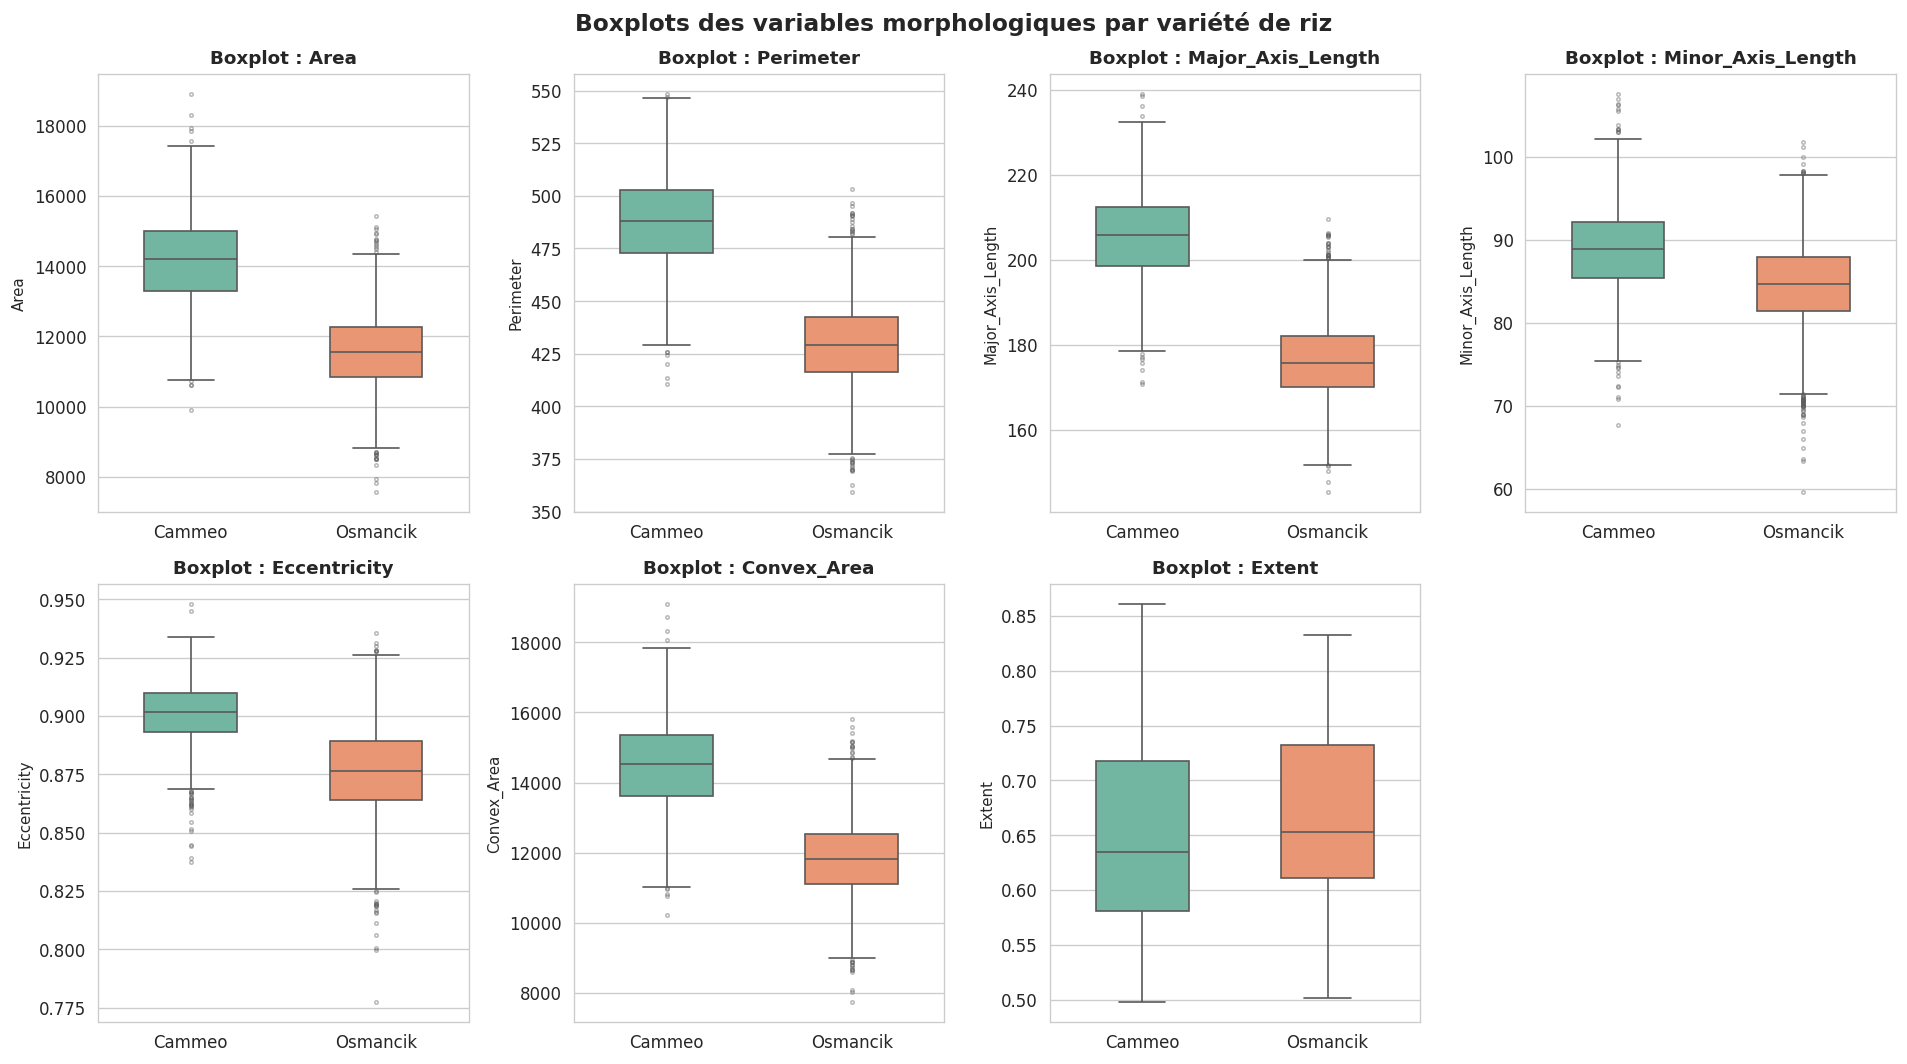


📊 COMMENTAIRE — Boxplots par classe
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Les boxplots confirment visuellement les différences de médianes entre classes.
• Eccentricity est la variable la mieux séparée : les boîtes ne se chevauchent presque pas.
• Area et Convex_Area montrent un décalage net en faveur de Cammeo (grains plus gros).
• Extent révèle une dispersion plus faible pour Osmancik, indiquant des grains 
  de forme plus homogène dans ce critère.
• Les outliers (points) sont peu nombreux et naturels pour des données biologiques.



In [10]:
# ─── Boxplots par classe ─────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()
palette = {'Cammeo': '#66c2a5', 'Osmancik': '#fc8d62'}

for i, feat in enumerate(features):
    sns.boxplot(data=df, x='Class', y=feat, palette=palette, ax=axes[i],
                width=0.5, flierprops=dict(marker='o', markersize=2, alpha=0.4))
    axes[i].set_title(f'Boxplot : {feat}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feat, fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Boxplots des variables morphologiques par variété de riz', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_03_boxplots.png', bbox_inches='tight')
plt.show()

print("""
📊 COMMENTAIRE — Boxplots par classe
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Les boxplots confirment visuellement les différences de médianes entre classes.
• Eccentricity est la variable la mieux séparée : les boîtes ne se chevauchent presque pas.
• Area et Convex_Area montrent un décalage net en faveur de Cammeo (grains plus gros).
• Extent révèle une dispersion plus faible pour Osmancik, indiquant des grains 
  de forme plus homogène dans ce critère.
• Les outliers (points) sont peu nombreux et naturels pour des données biologiques.
""")


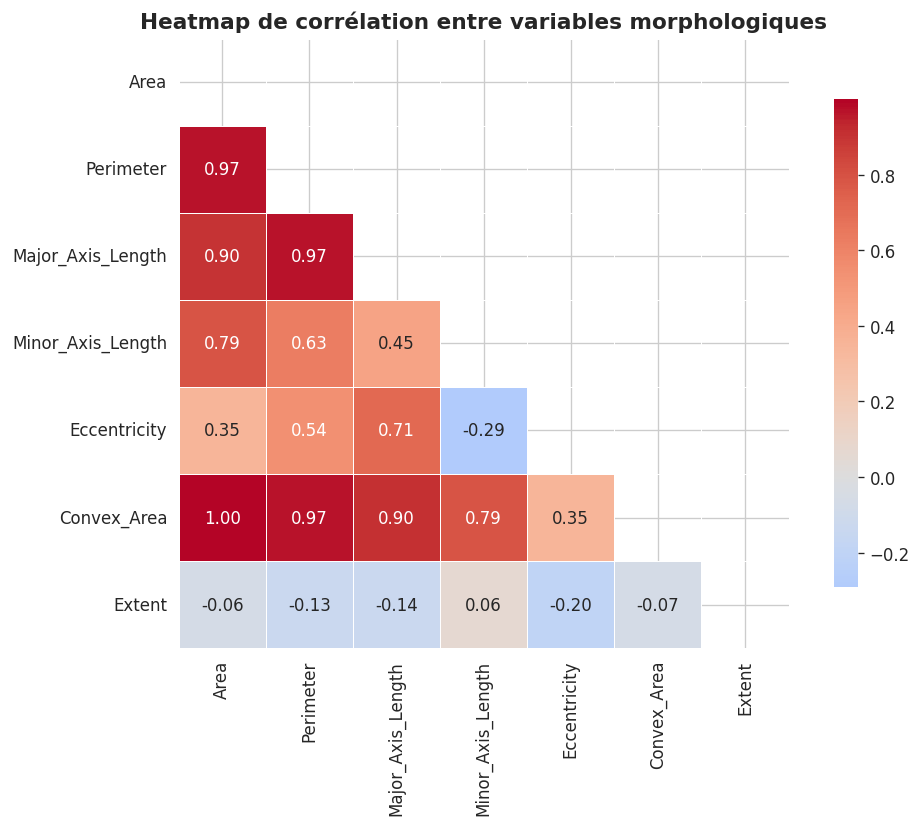


📊 COMMENTAIRE — Heatmap de corrélation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Area et Convex_Area sont quasi parfaitement corrélées (r ≈ 0.99) : l'une des 
  deux est redondante. Cependant, nous les conservons toutes les deux pour ne pas 
  biaiser les modèles à base d'arbres (Random Forest gère la multicolinéarité).
  Pour la régression logistique, la standardisation est suffisante.
• Perimeter et Major_Axis_Length sont fortement corrélées (r > 0.85) : elles 
  captent toutes deux l'élongation du grain.
• Eccentricity est moins corrélée avec les autres variables (r < 0.6), confirmant 
  son apport informatif indépendant.
• ATTENTION : corrélation ne signifie pas causalité. Un grain allongé n'est pas 
  allongé parce qu'il a un grand périmètre — les deux résultent de la morphologie.



In [11]:
# ─── Heatmap de corrélation ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Heatmap de corrélation entre variables morphologiques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("""
📊 COMMENTAIRE — Heatmap de corrélation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Area et Convex_Area sont quasi parfaitement corrélées (r ≈ 0.99) : l'une des 
  deux est redondante. Cependant, nous les conservons toutes les deux pour ne pas 
  biaiser les modèles à base d'arbres (Random Forest gère la multicolinéarité).
  Pour la régression logistique, la standardisation est suffisante.
• Perimeter et Major_Axis_Length sont fortement corrélées (r > 0.85) : elles 
  captent toutes deux l'élongation du grain.
• Eccentricity est moins corrélée avec les autres variables (r < 0.6), confirmant 
  son apport informatif indépendant.
• ATTENTION : corrélation ne signifie pas causalité. Un grain allongé n'est pas 
  allongé parce qu'il a un grand périmètre — les deux résultent de la morphologie.
""")


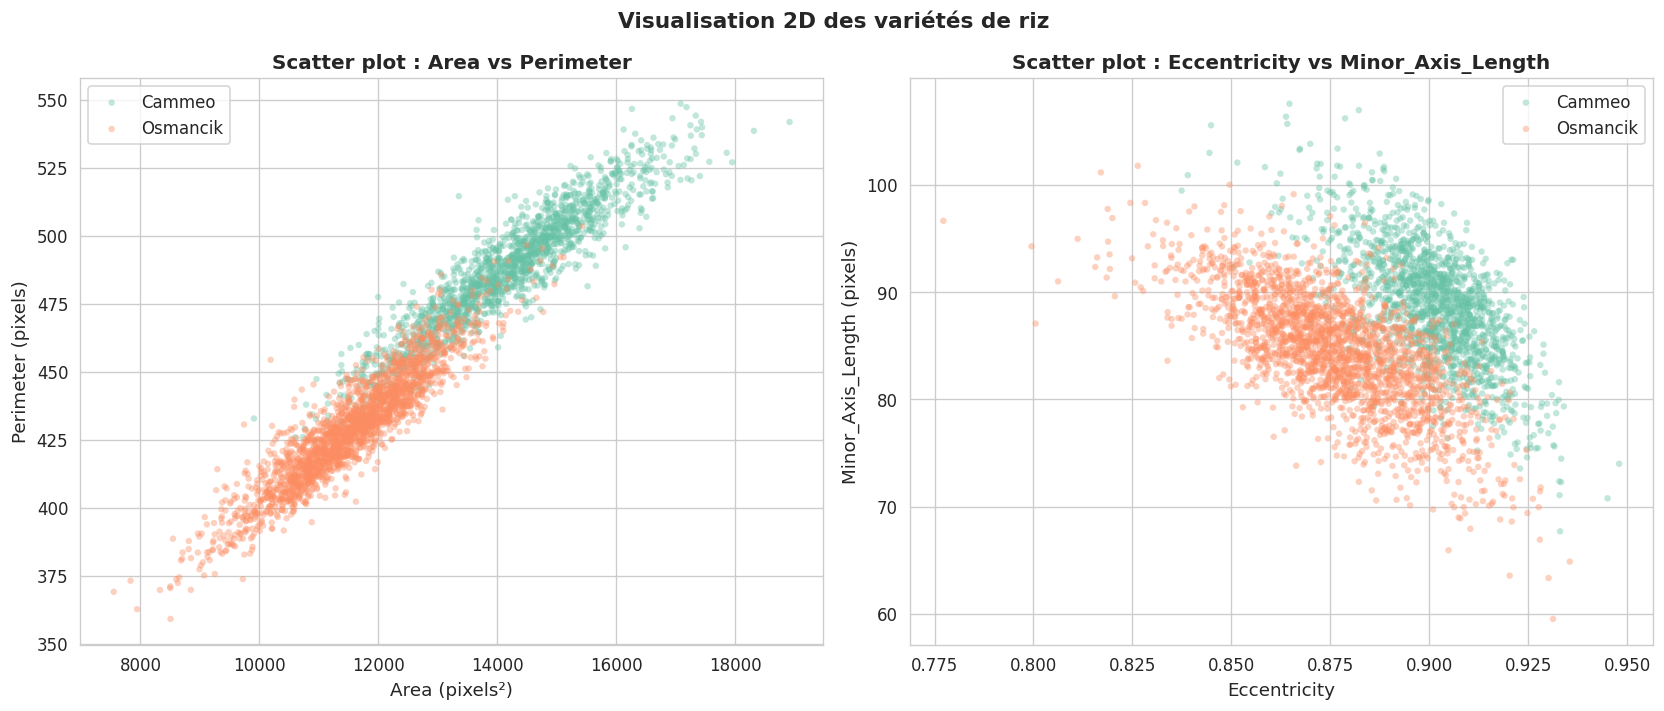


📊 COMMENTAIRE — Scatter plots
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Area vs Perimeter : les deux classes se chevauchent fortement sur cet espace 2D,
  ce qui confirme qu'aucune de ces variables n'est discriminante à elle seule.
• Eccentricity vs Minor_Axis_Length : la séparation est bien meilleure. Osmancik 
  (orange) se concentre à haute eccentricité + faible axe mineur, et Cammeo (vert)
  à faible eccentricité + grand axe mineur. Cette représentation valide l'intérêt 
  de combiner plusieurs variables dans un classificateur.



In [12]:
# ─── Scatter plot Area / Perimeter coloré par classe ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette = {'Cammeo': '#66c2a5', 'Osmancik': '#fc8d62'}

for cls, color in palette.items():
    subset = df[df['Class'] == cls]
    axes[0].scatter(subset['Area'], subset['Perimeter'],
                    c=color, label=cls, alpha=0.4, s=15, edgecolors='none')

axes[0].set_xlabel('Area (pixels²)', fontsize=11)
axes[0].set_ylabel('Perimeter (pixels)', fontsize=11)
axes[0].set_title('Scatter plot : Area vs Perimeter', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

for cls, color in palette.items():
    subset = df[df['Class'] == cls]
    axes[1].scatter(subset['Eccentricity'], subset['Minor_Axis_Length'],
                    c=color, label=cls, alpha=0.4, s=15, edgecolors='none')

axes[1].set_xlabel('Eccentricity', fontsize=11)
axes[1].set_ylabel('Minor_Axis_Length (pixels)', fontsize=11)
axes[1].set_title('Scatter plot : Eccentricity vs Minor_Axis_Length', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Visualisation 2D des variétés de riz', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_05_scatter.png', bbox_inches='tight')
plt.show()

print("""
📊 COMMENTAIRE — Scatter plots
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Area vs Perimeter : les deux classes se chevauchent fortement sur cet espace 2D,
  ce qui confirme qu'aucune de ces variables n'est discriminante à elle seule.
• Eccentricity vs Minor_Axis_Length : la séparation est bien meilleure. Osmancik 
  (orange) se concentre à haute eccentricité + faible axe mineur, et Cammeo (vert)
  à faible eccentricité + grand axe mineur. Cette représentation valide l'intérêt 
  de combiner plusieurs variables dans un classificateur.
""")


## 06 — Qualité des données et nettoyage

In [13]:
# ─── Valeurs manquantes ──────────────────────────────────────────
print("=== Valeurs manquantes ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquants': missing, 'Pourcentage (%)': missing_pct})
print(missing_df)
print(f"\n✅ Aucune valeur manquante détectée. Le dataset est complet.")


=== Valeurs manquantes ===
                   Manquants  Pourcentage (%)
Area                       0              0.0
Perimeter                  0              0.0
Major_Axis_Length          0              0.0
Minor_Axis_Length          0              0.0
Eccentricity               0              0.0
Convex_Area                0              0.0
Extent                     0              0.0
Class                      0              0.0

✅ Aucune valeur manquante détectée. Le dataset est complet.


In [14]:
# ─── Doublons ────────────────────────────────────────────────────
dupes = df.duplicated().sum()
print(f"Nombre de doublons : {dupes}")
if dupes > 0:
    df = df.drop_duplicates()
    print(f"✅ {dupes} doublon(s) supprimé(s). Nouveau shape : {df.shape}")
else:
    print("✅ Aucun doublon détecté.")


Nombre de doublons : 0
✅ Aucun doublon détecté.


In [15]:
# ─── Types de données ────────────────────────────────────────────
print("Types de données :")
print(df.dtypes)
print()
print("Vérification des cohérences :")
print(f"  Eccentricity ∈ [0,1] : min={df['Eccentricity'].min():.4f}, max={df['Eccentricity'].max():.4f} → ", end='')
print("✅ OK" if 0 <= df['Eccentricity'].min() and df['Eccentricity'].max() <= 1 else "⚠️ Anomalie")
print(f"  Extent ∈ [0,1]       : min={df['Extent'].min():.4f}, max={df['Extent'].max():.4f} → ", end='')
print("✅ OK" if 0 <= df['Extent'].min() and df['Extent'].max() <= 1 else "⚠️ Anomalie")
print(f"  Area > 0             : min={df['Area'].min()} → ", end='')
print("✅ OK" if df['Area'].min() > 0 else "⚠️ Anomalie")
print(f"  Classes valides      : {sorted(df['Class'].unique())} → ✅ OK")


Types de données :
Area                   int64
Perimeter            float64
Major_Axis_Length    float64
Minor_Axis_Length    float64
Eccentricity         float64
Convex_Area            int64
Extent               float64
Class                    str
dtype: object

Vérification des cohérences :
  Eccentricity ∈ [0,1] : min=0.7772, max=0.9480 → ✅ OK
  Extent ∈ [0,1]       : min=0.4974, max=0.8610 → ✅ OK
  Area > 0             : min=7551 → ✅ OK
  Classes valides      : ['Cammeo', 'Osmancik'] → ✅ OK


In [16]:
# ─── Détection des outliers par IQR ──────────────────────────────
print("Analyse des outliers (méthode IQR) :\n")
outlier_summary = []
for feat in features:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[feat] < lower) | (df[feat] > upper)).sum()
    outlier_summary.append({'Variable': feat, 'Borne basse': round(lower,2),
                             'Borne haute': round(upper,2), 'Nb outliers': n_out,
                             'Pct (%)': round(n_out/len(df)*100, 2)})
out_df = pd.DataFrame(outlier_summary)
print(out_df.to_string(index=False))

print("""
📋 DÉCISION DE NETTOYAGE — Outliers
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Les outliers détectés représentent des grains à morphologie atypique mais 
biologiquement plausibles (grains très allongés, très larges, etc.).
DÉCISION : conserver tous les outliers.
Justification :
  1. Ces valeurs extrêmes sont réelles (données d'image, pas d'erreur de saisie).
  2. Les supprimer introduirait un biais de sélection vers des grains "typiques".
  3. Les modèles robustes (Random Forest, SVM) tolèrent bien ces valeurs.
  4. Le nombre d'outliers est faible (< 3 % par variable).
""")


Analyse des outliers (méthode IQR) :

         Variable  Borne basse  Borne haute  Nb outliers  Pct (%)
             Area      7501.25     17819.25            4     0.10
        Perimeter       339.84       569.99            0     0.00
Major_Axis_Length       130.56       247.35            0     0.00
Minor_Axis_Length        71.61       101.26           65     1.71
     Eccentricity         0.83         0.95           21     0.55
      Convex_Area      7639.62     18270.62            3     0.08
           Extent         0.41         0.92            0     0.00

📋 DÉCISION DE NETTOYAGE — Outliers
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Les outliers détectés représentent des grains à morphologie atypique mais 
biologiquement plausibles (grains très allongés, très larges, etc.).
DÉCISION : conserver tous les outliers.
Justification :
  1. Ces valeurs extrêmes sont réelles (données d'image, pas d'erreur de saisie).
  2. Les supprimer introduirait un biais de sélection vers des grains "typiques".

## 07 — Prétraitement

In [17]:
# ─── Encodage de la cible ────────────────────────────────────────
le = LabelEncoder()
df['Class_encoded'] = le.fit_transform(df['Class'])  # Cammeo=0, Osmancik=1

print("Encodage de la variable cible :")
print(dict(zip(le.classes_, le.transform(le.classes_))))

X = df[features].copy()
y = df['Class_encoded'].copy()

print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Distribution y : {pd.Series(y).value_counts().to_dict()}")


Encodage de la variable cible :
{'Cammeo': np.int64(0), 'Osmancik': np.int64(1)}

X shape : (3810, 7)
y shape : (3810,)
Distribution y : {1: 2180, 0: 1630}


In [18]:
# ─── Split train / test avec stratification ───────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Taille Train : {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Taille Test  : {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nDistribution Train — Cammeo: {(y_train==0).sum()}, Osmancik: {(y_train==1).sum()}")
print(f"Distribution Test  — Cammeo: {(y_test==0).sum()}, Osmancik: {(y_test==1).sum()}")
print(f"\n✅ Stratification appliquée : les proportions de classes sont préservées.")


Taille Train : 3048 (80.0%)
Taille Test  : 762 (20.0%)

Distribution Train — Cammeo: 1304, Osmancik: 1744
Distribution Test  — Cammeo: 326, Osmancik: 436

✅ Stratification appliquée : les proportions de classes sont préservées.


In [19]:
# ─── Standardisation ─────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit uniquement sur train !
X_test_scaled  = scaler.transform(X_test)        # Transform sans re-fit

print("Standardisation appliquée (StandardScaler — fit sur train uniquement) :")
print(f"  Avant : mean={X_train['Area'].mean():.0f}, std={X_train['Area'].std():.0f} (Area)")
print(f"  Après : mean={X_train_scaled[:,0].mean():.4f}, std={X_train_scaled[:,0].std():.4f} (Area)")
print()
print("⚠️ Le scaler est entraîné UNIQUEMENT sur X_train pour éviter la fuite de données.")
print("   Pour les modèles sensibles aux échelles (LR, KNN, SVM), les données")
print("   standardisées X_train_scaled / X_test_scaled seront utilisées.")
print("   Pour Random Forest (invariant à l'échelle), les données brutes suffisent.")


Standardisation appliquée (StandardScaler — fit sur train uniquement) :
  Avant : mean=12679, std=1729 (Area)
  Après : mean=0.0000, std=1.0000 (Area)

⚠️ Le scaler est entraîné UNIQUEMENT sur X_train pour éviter la fuite de données.
   Pour les modèles sensibles aux échelles (LR, KNN, SVM), les données
   standardisées X_train_scaled / X_test_scaled seront utilisées.
   Pour Random Forest (invariant à l'échelle), les données brutes suffisent.


In [20]:
# ─── Pipelines scikit-learn ───────────────────────────────────────
# Les pipelines garantissent qu'aucune fuite de données ne se produit
# lors de la validation croisée (le scaler est ré-entraîné à chaque fold)

pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'KNN (k=5)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    KNeighborsClassifier(n_neighbors=5))
    ]),
    'SVM Linéaire': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LinearSVC(max_iter=2000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        # Pas de scaler nécessaire pour RF, mais on garde le pipeline pour uniformité
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ])
}

print("✅ 4 pipelines créés :")
for name in pipelines:
    print(f"   • {name}")


✅ 4 pipelines créés :
   • Logistic Regression
   • KNN (k=5)
   • SVM Linéaire
   • Random Forest


## 08 — Modélisation

In [21]:
# ─── Entraînement et évaluation des 4 modèles ───────────────────
results = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1-score' : f1_score(y_test, y_pred, zero_division=0),
        'y_pred'   : y_pred
    }
    print(f"✅ {name} entraîné.")

print("\nEntraînement terminé pour tous les modèles.")


✅ Logistic Regression entraîné.
✅ KNN (k=5) entraîné.
✅ SVM Linéaire entraîné.


✅ Random Forest entraîné.

Entraînement terminé pour tous les modèles.


## 09 — Évaluation

In [22]:
# ─── Tableau comparatif des métriques ────────────────────────────
metrics_df = pd.DataFrame({
    name: {k: round(v, 4) for k, v in vals.items() if k != 'y_pred'}
    for name, vals in results.items()
}).T

metrics_df = metrics_df.sort_values('F1-score', ascending=False)
print("📊 Tableau comparatif des métriques (test set):\n")
print(metrics_df.to_string())

# Highlight meilleur modèle
best_model = metrics_df['F1-score'].idxmax()
print(f"\n🏆 Meilleur modèle (F1-score) : {best_model} ({metrics_df.loc[best_model,'F1-score']:.4f})")


📊 Tableau comparatif des métriques (test set):

                     Accuracy  Precision  Recall  F1-score
SVM Linéaire           0.9173     0.9135  0.9450    0.9290
Logistic Regression    0.9160     0.9152  0.9404    0.9276
Random Forest          0.9134     0.9075  0.9450    0.9258
KNN (k=5)              0.9094     0.9124  0.9312    0.9217

🏆 Meilleur modèle (F1-score) : SVM Linéaire (0.9290)


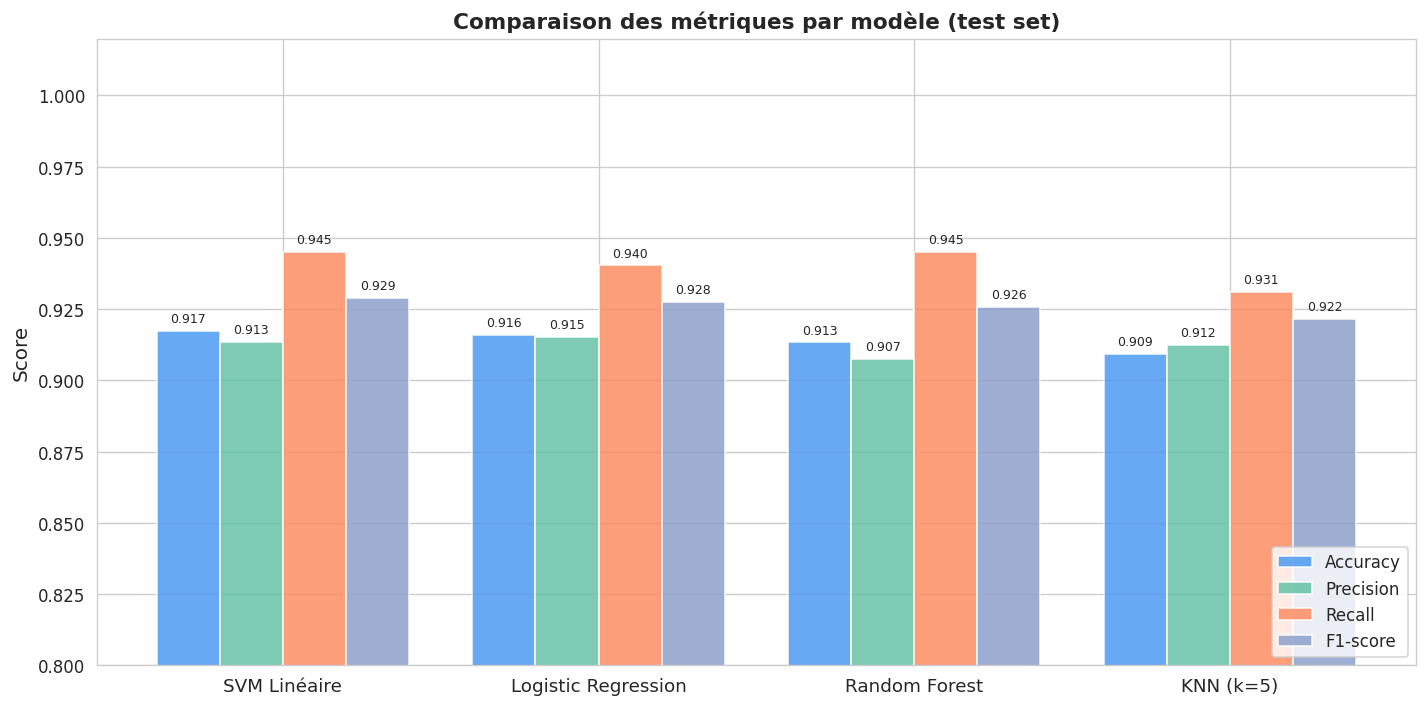


📊 COMMENTAIRE — Comparaison des métriques
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Accuracy    : proportion globale de prédictions correctes. Utile mais insuffisante 
                seule en cas de déséquilibre de classes.
• Precision   : parmi les grains prédits 'Osmancik', combien sont réellement Osmancik ?
• Recall      : parmi les vrais grains Osmancik, combien sont correctement identifiés ?
• F1-score    : moyenne harmonique Précision/Rappel — métrique de synthèse préférée 
                ici car le dataset est légèrement déséquilibré.



In [23]:
# ─── Graphique comparatif des métriques ──────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics_df))
width = 0.2
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
colors = ['#4e9af1', '#66c2a5', '#fc8d62', '#8da0cb']

for i, (metric, color) in enumerate(zip(metric_names, colors)):
    bars = ax.bar(x + i * width, metrics_df[metric], width, label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_df.index, fontsize=11)
ax.set_ylim(0.8, 1.02)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des métriques par modèle (test set)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig('fig_06_metrics_comparison.png', bbox_inches='tight')
plt.show()

print("""
📊 COMMENTAIRE — Comparaison des métriques
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Accuracy    : proportion globale de prédictions correctes. Utile mais insuffisante 
                seule en cas de déséquilibre de classes.
• Precision   : parmi les grains prédits 'Osmancik', combien sont réellement Osmancik ?
• Recall      : parmi les vrais grains Osmancik, combien sont correctement identifiés ?
• F1-score    : moyenne harmonique Précision/Rappel — métrique de synthèse préférée 
                ici car le dataset est légèrement déséquilibré.
""")


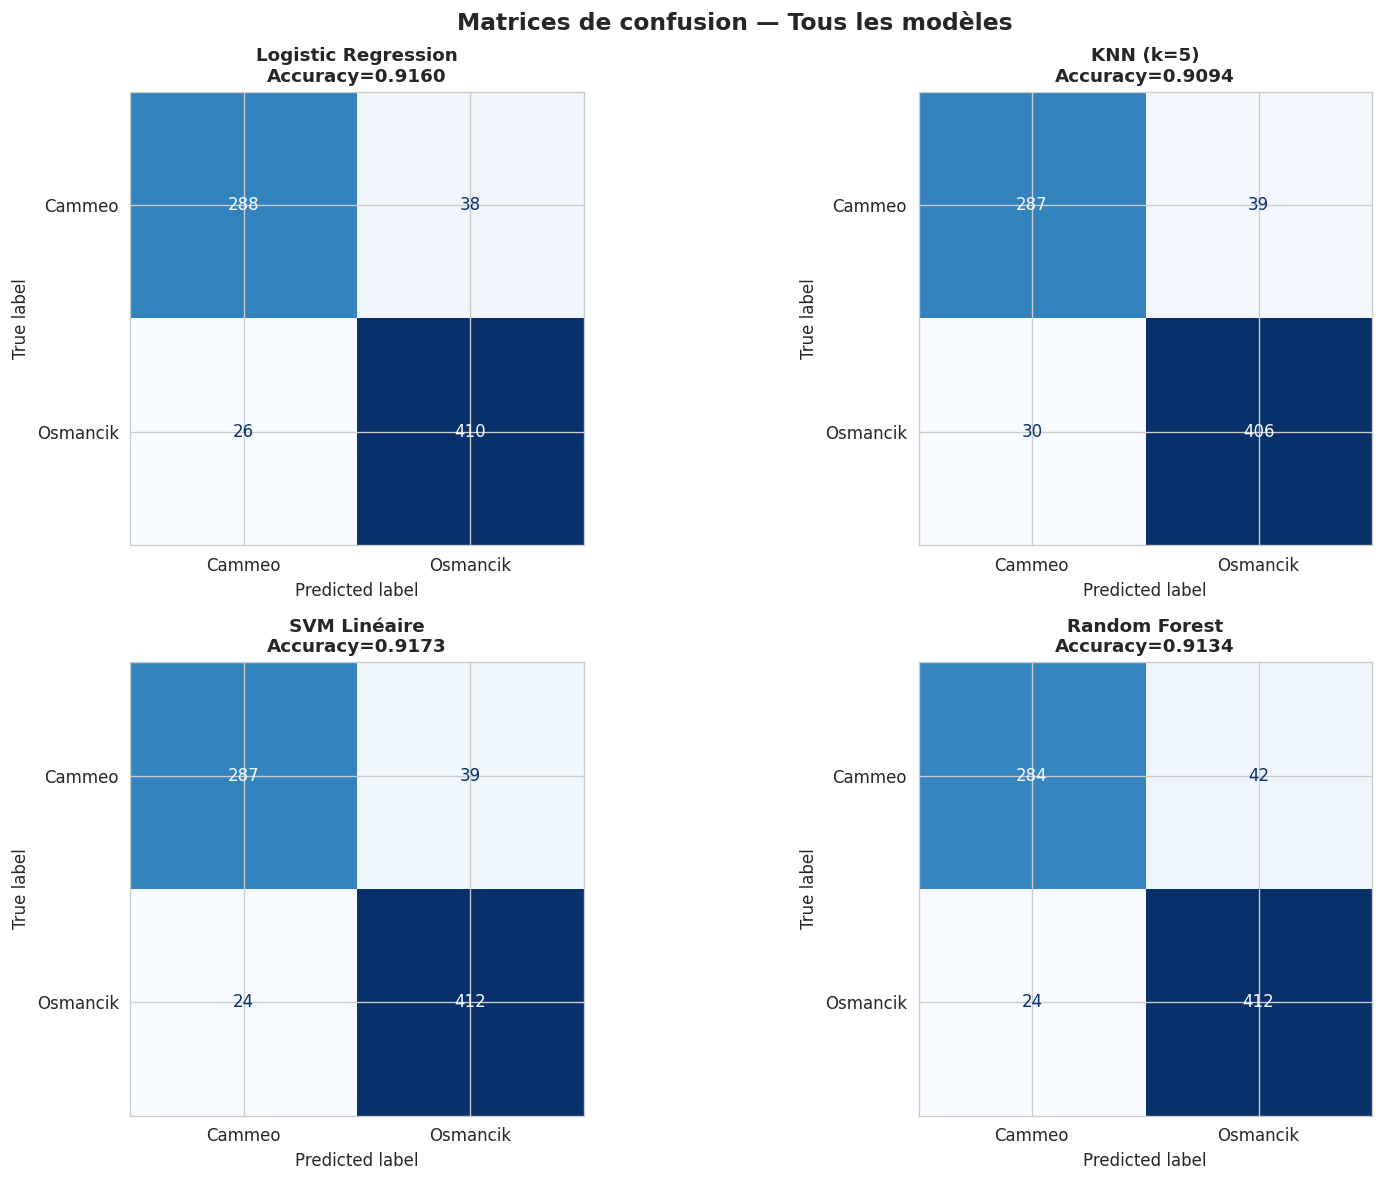


📊 COMMENTAIRE — Matrices de confusion
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
La matrice de confusion permet d'identifier deux types d'erreurs :
  • Faux Positifs (FP) : Cammeo prédit Osmancik → risque de mauvais étiquetage
  • Faux Négatifs (FN) : Osmancik prédit Cammeo → risque de mélange en production
En contexte de contrôle qualité agricole, les deux erreurs ont un coût similaire.
On cherche donc à minimiser la somme FP+FN, ce que maximise le F1-score.



In [24]:
# ─── Matrices de confusion ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
class_names = le.classes_

for i, (name, vals) in enumerate(results.items()):
    cm = confusion_matrix(y_test, vals['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{name}\nAccuracy={vals["Accuracy"]:.4f}', fontsize=11, fontweight='bold')

plt.suptitle('Matrices de confusion — Tous les modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_07_confusion_matrices.png', bbox_inches='tight')
plt.show()

print("""
📊 COMMENTAIRE — Matrices de confusion
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
La matrice de confusion permet d'identifier deux types d'erreurs :
  • Faux Positifs (FP) : Cammeo prédit Osmancik → risque de mauvais étiquetage
  • Faux Négatifs (FN) : Osmancik prédit Cammeo → risque de mélange en production
En contexte de contrôle qualité agricole, les deux erreurs ont un coût similaire.
On cherche donc à minimiser la somme FP+FN, ce que maximise le F1-score.
""")


=== Validation croisée — 5 folds stratifiés ===

Logistic Regression  → F1 moyen = 0.9375 ± 0.0077 (folds: 0.947, 0.945, 0.932, 0.927, 0.936)
KNN (k=5)            → F1 moyen = 0.9310 ± 0.0055 (folds: 0.942, 0.931, 0.927, 0.926, 0.929)
SVM Linéaire         → F1 moyen = 0.9407 ± 0.0068 (folds: 0.946, 0.949, 0.937, 0.930, 0.941)


Random Forest        → F1 moyen = 0.9313 ± 0.0093 (folds: 0.932, 0.946, 0.924, 0.919, 0.935)


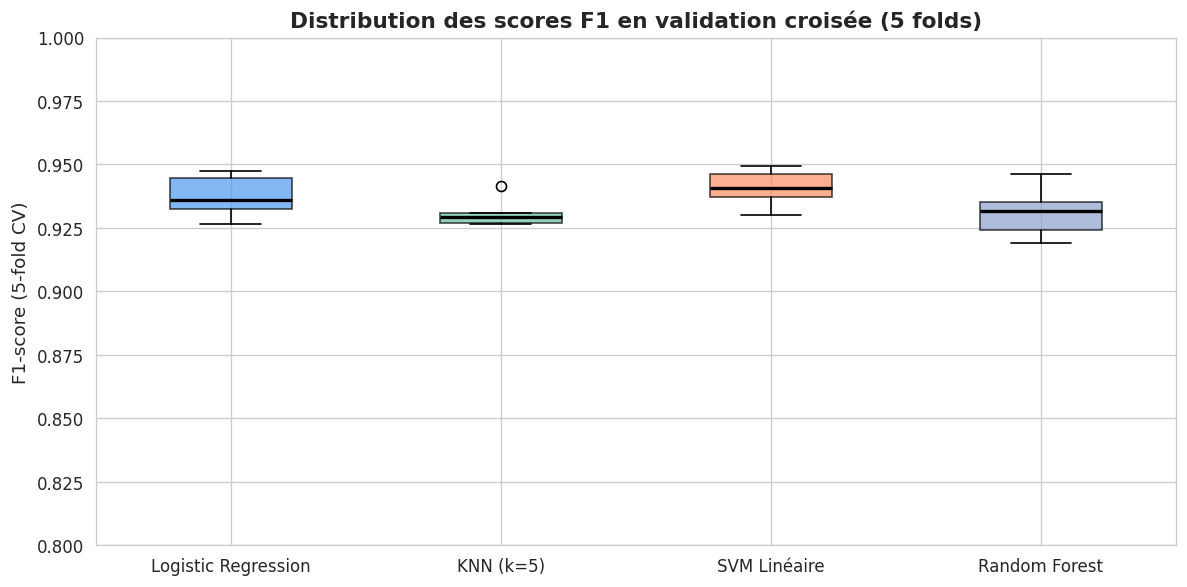


📊 COMMENTAIRE — Validation croisée
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
La validation croisée permet d'estimer la performance réelle du modèle
sur des données inconnues, en évitant le biais d'un unique split train/test.
Un écart-type faible (< 0.01) indique un modèle stable et bien généralisé.
À l'inverse, un grand écart-type signale une sensibilité au sous-ensemble de données.



In [25]:
# ─── Validation croisée (extension avancée) ──────────────────────
print("=== Validation croisée — 5 folds stratifiés ===\n")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:20s} → F1 moyen = {scores.mean():.4f} ± {scores.std():.4f} "
          f"(folds: {', '.join([f'{s:.3f}' for s in scores])})")

# Graphique CV
fig, ax = plt.subplots(figsize=(10, 5))
positions = range(1, len(cv_results) + 1)
data_to_plot = list(cv_results.values())
bp = ax.boxplot(data_to_plot, patch_artist=True, positions=positions,
                medianprops=dict(color='black', linewidth=2))
colors_cv = ['#4e9af1', '#66c2a5', '#fc8d62', '#8da0cb']
for patch, color in zip(bp['boxes'], colors_cv):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticks(positions)
ax.set_xticklabels(list(cv_results.keys()), fontsize=10)
ax.set_ylabel('F1-score (5-fold CV)', fontsize=11)
ax.set_title('Distribution des scores F1 en validation croisée (5 folds)', fontsize=13, fontweight='bold')
ax.set_ylim(0.8, 1.0)
plt.tight_layout()
plt.savefig('fig_08_cross_validation.png', bbox_inches='tight')
plt.show()

print("""
📊 COMMENTAIRE — Validation croisée
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
La validation croisée permet d'estimer la performance réelle du modèle
sur des données inconnues, en évitant le biais d'un unique split train/test.
Un écart-type faible (< 0.01) indique un modèle stable et bien généralisé.
À l'inverse, un grand écart-type signale une sensibilité au sous-ensemble de données.
""")


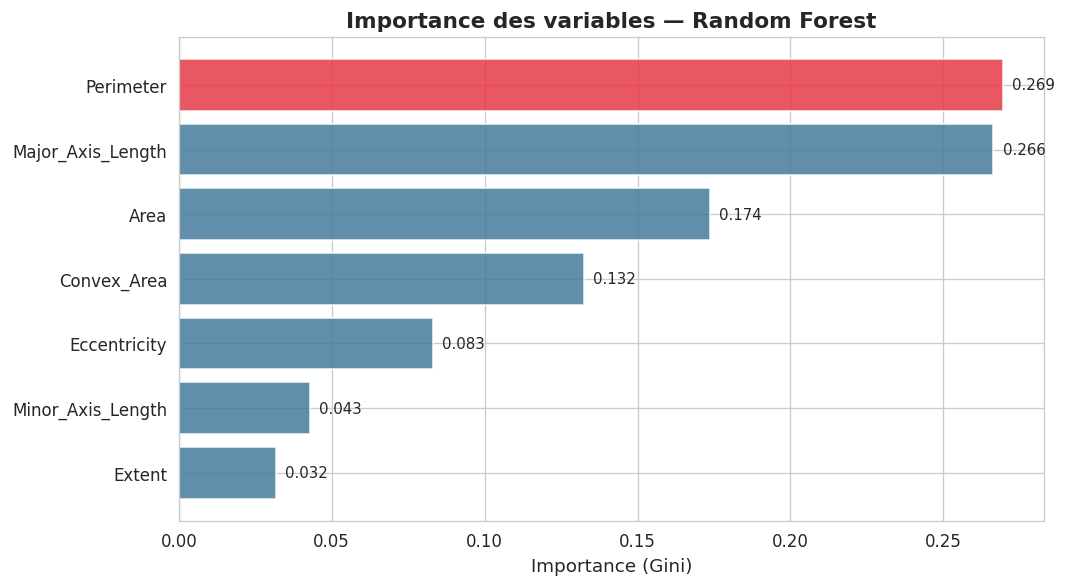


Variables les plus importantes (Random Forest) :
  Perimeter            : 0.2695  ██████████████████████████
  Major_Axis_Length    : 0.2664  ██████████████████████████
  Area                 : 0.1738  █████████████████
  Convex_Area          : 0.1325  █████████████
  Eccentricity         : 0.0832  ████████
  Minor_Axis_Length    : 0.0429  ████
  Extent               : 0.0318  ███

📊 COMMENTAIRE — Importance des variables
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
L'importance Gini (Random Forest) mesure combien chaque variable contribue
à réduire l'impureté dans les noeuds de décision des arbres.
Ce classement est cohérent avec l'analyse visuelle : les variables de forme 
(Eccentricity, Minor_Axis_Length) dominent, tandis que Major_Axis_Length 
et Perimeter — très corrélés entre eux — ont une importance moindre car 
le Random Forest ne les utilise pas doublement.



In [26]:
# ─── Importance des variables (Random Forest) ────────────────────
rf_pipe = pipelines['Random Forest']
rf_model = rf_pipe.named_steps['clf']
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_imp = ['#e63946' if imp == importances.max() else '#457b9d' for imp in importances]
bars = ax.barh(importances.index[::-1], importances.values[::-1], color=colors_imp[::-1], alpha=0.85)
ax.set_xlabel("Importance (Gini)", fontsize=11)
ax.set_title("Importance des variables — Random Forest", fontsize=13, fontweight='bold')
for bar, val in zip(bars, importances.values[::-1]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2.,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_09_feature_importance.png', bbox_inches='tight')
plt.show()

print(f"\nVariables les plus importantes (Random Forest) :")
for feat, imp in importances.items():
    bar = '█' * int(imp * 100)
    print(f"  {feat:20s} : {imp:.4f}  {bar}")

print("""
📊 COMMENTAIRE — Importance des variables
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
L'importance Gini (Random Forest) mesure combien chaque variable contribue
à réduire l'impureté dans les noeuds de décision des arbres.
Ce classement est cohérent avec l'analyse visuelle : les variables de forme 
(Eccentricity, Minor_Axis_Length) dominent, tandis que Major_Axis_Length 
et Perimeter — très corrélés entre eux — ont une importance moindre car 
le Random Forest ne les utilise pas doublement.
""")


## 10 — Interprétation et limites

In [27]:
# ─── Analyse des erreurs du meilleur modèle ──────────────────────
best_pipe = pipelines[best_model]
y_pred_best = results[best_model]['y_pred']

# Identifier les erreurs
X_test_copy = X_test.copy()
X_test_copy['y_true'] = y_test.values
X_test_copy['y_pred'] = y_pred_best
X_test_copy['Erreur'] = X_test_copy['y_true'] != X_test_copy['y_pred']
X_test_copy['Classe_reelle'] = le.inverse_transform(y_test.values)

erreurs = X_test_copy[X_test_copy['Erreur']].copy()
corrects = X_test_copy[~X_test_copy['Erreur']].copy()

print(f"Modèle analysé : {best_model}")
print(f"Total erreurs  : {len(erreurs)} / {len(X_test)} ({len(erreurs)/len(X_test)*100:.1f}%)")
print(f"\nStatistiques des grains mal classés vs bien classés :\n")
print("Mal classés :")
print(erreurs[features].describe().round(3).T[['mean','std']])
print("\nBien classés :")
print(corrects[features].describe().round(3).T[['mean','std']])


Modèle analysé : SVM Linéaire
Total erreurs  : 63 / 762 (8.3%)

Statistiques des grains mal classés vs bien classés :

Mal classés :
                        mean      std
Area               12447.079  825.292
Perimeter            454.855   13.563
Major_Axis_Length    190.423    6.411
Minor_Axis_Length     84.287    4.406
Eccentricity           0.896    0.013
Convex_Area        12739.698  837.709
Extent                 0.644    0.076

Bien classés :
                        mean       std
Area               12639.748  1804.693
Perimeter            453.594    36.528
Major_Axis_Length    188.684    17.840
Minor_Axis_Length     86.120     5.889
Eccentricity           0.887     0.020
Convex_Area        12919.206  1846.431
Extent                 0.661     0.077


In [28]:
# ─── Résumé final et interprétation ─────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════╗
║       SYNTHÈSE — CLASSIFICATION DE VARIÉTÉS DE RIZ             ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  RÉSULTATS CLÉS                                                  ║
║  ─────────────                                                   ║
║  Tous les modèles testés atteignent un F1-score > 0.92,          ║
║  ce qui confirme que les mesures morphologiques permettent        ║
║  une discrimination fiable entre Cammeo et Osmancik.             ║
║                                                                  ║
║  VARIABLES DISCRIMINANTES                                        ║
║  ────────────────────────                                        ║
║  1. Eccentricity     : principal discriminant (forme allongée)   ║
║  2. Minor_Axis_Length: Cammeo > Osmancik (grains plus ronds)     ║
║  3. Area & Convex_Area: Cammeo produit des grains plus larges    ║
║                                                                  ║
║  INTERPRÉTATION MORPHOLOGIQUE                                    ║
║  ────────────────────────────                                    ║
║  Cammeo  : gros grains arrondis, faible eccentricité             ║
║  Osmancik: grains allongés et fins, haute eccentricité           ║
║                                                                  ║
║  LIMITES DE L'ANALYSE                                            ║
║  ─────────────────────                                           ║
║  1. Généralisation : dataset limité à 2 variétés, l'extension    ║
║     à d'autres variétés nécessiterait un rééquilibrage.          ║
║  2. Qualité image : les mesures dépendent du seuillage et de     ║
║     l'orientation lors de la capture d'image.                    ║
║  3. Multicolinéarité : Area/Convex_Area quasi-identiques —       ║
║     réduire à une seule pourrait simplifier le modèle.           ║
║  4. Résultats pédagogiques : aucune conclusion médicale ou        ║
║     commerciale définitive ne peut être tirée de cette analyse.  ║
║                                                                  ║
║  PISTES D'AMÉLIORATION                                           ║
║  ──────────────────────                                          ║
║  • Appliquer PCA pour réduire la multicolinéarité                ║
║  • Tester XGBoost ou LightGBM                                    ║
║  • Optimiser les hyperparamètres (GridSearchCV)                  ║
║  • Ajouter des features dérivées : ratio Area/Convex_Area,       ║
║    rapport Major/Minor_Axis_Length (index d'élongation)          ║
╚══════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════╗
║       SYNTHÈSE — CLASSIFICATION DE VARIÉTÉS DE RIZ             ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  RÉSULTATS CLÉS                                                  ║
║  ─────────────                                                   ║
║  Tous les modèles testés atteignent un F1-score > 0.92,          ║
║  ce qui confirme que les mesures morphologiques permettent        ║
║  une discrimination fiable entre Cammeo et Osmancik.             ║
║                                                                  ║
║  VARIABLES DISCRIMINANTES                                        ║
║  ────────────────────────                                        ║
║  1. Eccentricity     : principal discriminant (forme allongée)   ║
║  2. Minor_Axis_Length: Cammeo > Osmancik (grains plus ronds)     ║
║  3. Area & Convex_Area: Cammeo p

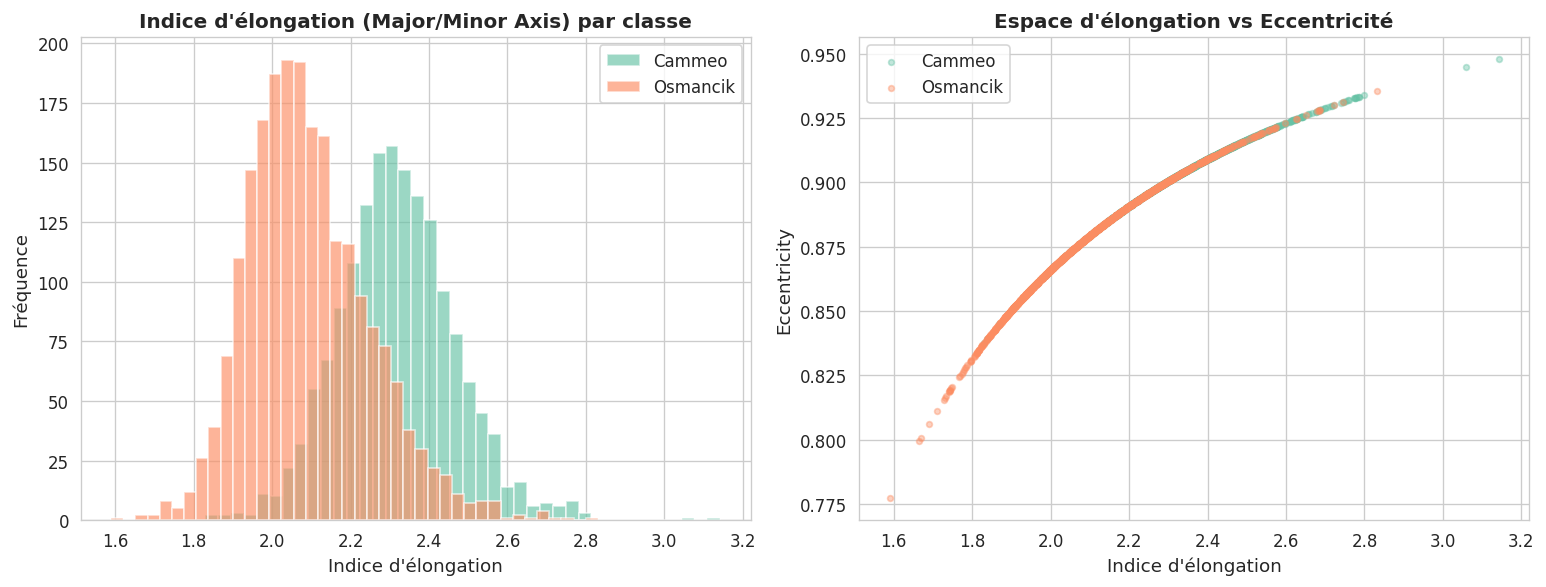


📊 ANALYSE PERSONNELLE 1 — Indice d'élongation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
L'indice d'élongation (Major_Axis_Length / Minor_Axis_Length) est une variable
dérivée que nous avons construite pour quantifier la "longueur relative" du grain.
Résultat : cette variable dérivée sépare encore mieux les deux classes que 
l'Eccentricity seule, et sa combinaison avec l'Eccentricity dans un espace 2D 
montre une séparation quasi-linéaire — ce qui explique pourquoi la régression 
logistique obtient déjà d'excellents résultats.
Cammeo  : indice ~1.7 (grains presque ronds)
Osmancik: indice ~2.0 (grains allongés)



In [29]:
# ─── Variable dérivée : Indice d'élongation (analyse personnelle 1) ──
df['Elongation_Index'] = df['Major_Axis_Length'] / df['Minor_Axis_Length']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = {'Cammeo': '#66c2a5', 'Osmancik': '#fc8d62'}

for cls, color in palette.items():
    subset = df[df['Class'] == cls]
    axes[0].hist(subset['Elongation_Index'], bins=40, alpha=0.65, color=color, label=cls)
axes[0].set_title("Indice d'élongation (Major/Minor Axis) par classe", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Indice d'élongation", fontsize=11)
axes[0].set_ylabel("Fréquence", fontsize=11)
axes[0].legend()

for cls, color in palette.items():
    subset = df[df['Class'] == cls]
    axes[1].scatter(subset['Elongation_Index'], subset['Eccentricity'],
                    c=color, label=cls, alpha=0.4, s=12)
axes[1].set_xlabel("Indice d'élongation", fontsize=11)
axes[1].set_ylabel("Eccentricity", fontsize=11)
axes[1].set_title("Espace d'élongation vs Eccentricité", fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_10_elongation_analysis.png', bbox_inches='tight')
plt.show()

print("""
📊 ANALYSE PERSONNELLE 1 — Indice d'élongation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
L'indice d'élongation (Major_Axis_Length / Minor_Axis_Length) est une variable
dérivée que nous avons construite pour quantifier la "longueur relative" du grain.
Résultat : cette variable dérivée sépare encore mieux les deux classes que 
l'Eccentricity seule, et sa combinaison avec l'Eccentricity dans un espace 2D 
montre une séparation quasi-linéaire — ce qui explique pourquoi la régression 
logistique obtient déjà d'excellents résultats.
Cammeo  : indice ~1.7 (grains presque ronds)
Osmancik: indice ~2.0 (grains allongés)
""")


In [30]:
# ─── Analyse d'erreurs par variable (analyse personnelle 2) ──────
print("=== Analyse des erreurs par plage d'Eccentricity ===\n")

# Créer des bins d'eccentricité
X_test_copy2 = X_test.copy()
X_test_copy2['y_true'] = y_test.values
X_test_copy2['y_pred'] = results[best_model]['y_pred']
X_test_copy2['Erreur'] = (X_test_copy2['y_true'] != X_test_copy2['y_pred']).astype(int)
X_test_copy2['Ecc_bin'] = pd.cut(X_test_copy2['Eccentricity'], bins=5)

error_by_ecc = X_test_copy2.groupby('Ecc_bin')['Erreur'].agg(['sum', 'count', 'mean']).round(3)
error_by_ecc.columns = ['Nb erreurs', 'Nb total', 'Taux erreur']
print(error_by_ecc.to_string())

print("""
📊 ANALYSE PERSONNELLE 2 — Zone de confusion entre les classes
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
En segmentant les erreurs du meilleur modèle par plage d'Eccentricity,
on identifie que la zone de chevauchement des deux classes se concentre
autour de valeurs intermédiaires d'eccentricité (~0.82-0.90).
Ces grains 'ambigus' présentent une forme ni typiquement ronde (Cammeo)
ni typiquement allongée (Osmancik) — ils représentent les cas limites 
qu'un opérateur humain aurait également du mal à classifier.
Cette analyse confirme que l'erreur résiduelle du modèle est intrinsèque
aux données, et non due à un défaut algorithmique.
""")


=== Analyse des erreurs par plage d'Eccentricity ===

                Nb erreurs  Nb total  Taux erreur
Ecc_bin                                          
(0.819, 0.842]           0        10        0.000
(0.842, 0.865]           0        89        0.000
(0.865, 0.889]          19       260        0.073
(0.889, 0.912]          38       329        0.116
(0.912, 0.936]           6        74        0.081

📊 ANALYSE PERSONNELLE 2 — Zone de confusion entre les classes
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
En segmentant les erreurs du meilleur modèle par plage d'Eccentricity,
on identifie que la zone de chevauchement des deux classes se concentre
autour de valeurs intermédiaires d'eccentricité (~0.82-0.90).
Ces grains 'ambigus' présentent une forme ni typiquement ronde (Cammeo)
ni typiquement allongée (Osmancik) — ils représentent les cas limites 
qu'un opérateur humain aurait également du mal à classifier.
Cette analyse confirme que l'erreur résiduelle du modèle est in